# Econometrics — Seminar 6
## Linear Probability Model and Logistic Regression
Dataset: Ames Housing (`data/data.csv`)

> Working variable: `EH = 1` if `SalePrice > 130000`, otherwise `EH = 0`.

> Note: tasks below are copied from the seminar handout.

In [2]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm

In [3]:
df = pd.read_csv('data/data.csv')

## Task 1
Run and analyze linear probability model for `EH` on `OverallQual`, `GrLivArea`, `TotalBsmtSF`, `YearBuilt`, `GarageCars`. Explain possible drawbacks of this approach. Does the model satisfy Classical Linear Model assumptions?

In [4]:
predictors = ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'Garage Cars']
df = df.dropna(subset=predictors + ['SalePrice']).copy()
df['EH'] = (df['SalePrice'] > 130000).astype(int)

X = sm.add_constant(df[predictors])
y = df['EH']

lpm = sm.OLS(y, X).fit()
print(lpm.summary())

pred = lpm.predict(X)
print(f'Predicted values in [0,1]: {((pred >= 0) & (pred <= 1)).mean():.3f}')
print(f'Predicted values < 0: {(pred < 0).sum()}')
print(f'Predicted values > 1: {(pred > 1).sum()}')

# Drawbacks of LPM:
# 1. Predicted probabilities can be outside [0,1].
# 2. Heteroskedasticity of errors.

                            OLS Regression Results                            
Dep. Variable:                     EH   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     400.4
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:58:57   Log-Likelihood:                -993.43
No. Observations:                2928   AIC:                             1999.
Df Residuals:                    2922   BIC:                             2035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -7.7210      0.531    -14.546

## Task 2
Run logistic regression for `EH` on `OverallQual`, `GrLivArea`, `TotalBsmtSF`, `YearBuilt`, `GarageCars`. Explain in your own words how the logistic model is constructed. Present the obtained outcome.

In [6]:
# Task 2: Logistic regression for EH
import numpy as np
from pathlib import Path

canonical_predictors = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'GarageCars']
candidate_names = {
    'OverallQual': ['OverallQual', 'Overall Qual'],
    'GrLivArea': ['GrLivArea', 'Gr Liv Area'],
    'TotalBsmtSF': ['TotalBsmtSF', 'Total Bsmt SF'],
    'YearBuilt': ['YearBuilt', 'Year Built'],
    'GarageCars': ['GarageCars', 'Garage Cars'],
    'SalePrice': ['SalePrice', 'Sale Price']
}

def pick_col(frame, names):
    for name in names:
        if name in frame.columns:
            return name
    return None

# If in-memory df lacks required columns, reload raw data
required_for_logit = canonical_predictors + ['SalePrice']
if not all(col in df.columns for col in required_for_logit):
    for p in [Path('data/data.csv'), Path('seminar_6/data/data.csv')]:
        if p.exists():
            df = pd.read_csv(p)
            break

# Build renamed frame with canonical names
resolved = {k: pick_col(df, v) for k, v in candidate_names.items()}
missing = [k for k, v in resolved.items() if v is None]
if missing:
    raise ValueError(f'Missing required columns in dataset: {missing}')

task2_df = df[[resolved['SalePrice']] + [resolved[k] for k in canonical_predictors]].copy()
task2_df.columns = ['SalePrice'] + canonical_predictors
task2_df['EH'] = (task2_df['SalePrice'] > 130000).astype(int)
task2_df = task2_df.dropna(subset=canonical_predictors + ['EH'])

X_logit = sm.add_constant(task2_df[canonical_predictors])
y_logit = task2_df['EH']

logit_model = sm.Logit(y_logit, X_logit).fit(disp=False)
print(logit_model.summary())

# Predicted probabilities
task2_df['p_hat'] = logit_model.predict(X_logit)
print('\nPredicted probability summary:')
print(task2_df['p_hat'].describe())

                           Logit Regression Results                           
Dep. Variable:                     EH   No. Observations:                 2928
Model:                          Logit   Df Residuals:                     2922
Method:                           MLE   Df Model:                            5
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.5496
Time:                        12:59:00   Log-Likelihood:                -761.73
converged:                       True   LL-Null:                       -1691.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -84.5713      6.027    -14.032      0.000     -96.384     -72.758
OverallQual     0.9374      0.086     10.860      0.000       0.768       1.107
GrLivArea       0.0030      0.000     13.093    

## Task 3
How can we interpret estimated coefficients? Choose one independent variable and provide correct interpretation of its parameter using odds.

## Task 4
Discuss which variables increase probability of `SalePrice > 130000` (`EH = 1`) and which decrease it. Do the results coincide with your intuition?

## Task 5
Discuss model goodness of fit. Calculate pseudo `R^2`. What does it show? Why is pseudo `R^2` not directly comparable to OLS `R^2`?

## Task 6
Choose 5 different observations and compute predicted probability of `EH = 1` using the estimated model. Provide the formula used.

In [7]:
# Task 6: Predicted probability for 5 selected observations
# Formula: P(EH=1 | X) = 1 / (1 + exp(-X @ beta))

print("Formula: P(EH=1 | X) = 1 / (1 + exp(-(b0 + b1*OverallQual + b2*GrLivArea + b3*TotalBsmtSF + b4*YearBuilt + b5*GarageCars)))")
print()

sample_indices = [0, 250, 500, 750, 1000]

# Use task2_df (already renamed to canonical predictor names and contains EH)
sample = task2_df.loc[sample_indices, canonical_predictors + ['EH']].copy()

X_sample = sm.add_constant(sample[canonical_predictors], has_constant='add')
sample['linear_predictor'] = X_sample @ logit_model.params
sample['p_hat_manual'] = 1 / (1 + np.exp(-sample['linear_predictor']))

# Verify against model's built-in predict
sample['p_hat_model'] = logit_model.predict(X_sample)

display_cols = canonical_predictors + ['EH', 'linear_predictor', 'p_hat_manual', 'p_hat_model']
print(sample[display_cols].to_string())


Formula: P(EH=1 | X) = 1 / (1 + exp(-(b0 + b1*OverallQual + b2*GrLivArea + b3*TotalBsmtSF + b4*YearBuilt + b5*GarageCars)))

      OverallQual  GrLivArea  TotalBsmtSF  YearBuilt  GarageCars  EH  linear_predictor  p_hat_manual  p_hat_model
0               6       1656       1080.0       1960         2.0   1          3.366144      0.966630     0.966630
250             7       1208       1187.0       2006         2.0   1          4.925890      0.992796     0.992796
500             8       2063       2024.0       1994         3.0   1         10.633687      0.999976     0.999976
750             7       1826        910.0       1915         1.0   1          1.899814      0.869870     0.869870
1000            8       1682       1664.0       1997         2.0   1          7.974209      0.999656     0.999656


## Task 7
If you want to predict whether a house has high sale price (`> 130000`), what is the simplest way to do this using logistic model? Compare those results with true values for the selected 5 observations.

In [8]:
# Task 7: Simplest prediction — round predicted probability at threshold 0.5
# If p_hat >= 0.5 → predict EH = 1, else EH = 0

THRESHOLD_DEFAULT = 0.5

sample['EH_pred'] = (sample['p_hat_model'] >= THRESHOLD_DEFAULT).astype(int)

print(f"Classification threshold: {THRESHOLD_DEFAULT}")
print()
print(
    sample[['EH', 'p_hat_model', 'EH_pred']]
    .rename(columns={'EH': 'True EH', 'p_hat_model': 'P(EH=1)', 'EH_pred': 'Predicted EH'})
    .to_string()
)
print()
correct = (sample['EH_pred'] == sample['EH']).sum()
print(f"Correctly classified: {correct} / {len(sample)}")


Classification threshold: 0.5

      True EH   P(EH=1)  Predicted EH
0           1  0.966630             1
250         1  0.992796             1
500         1  0.999976             1
750         1  0.869870             1
1000        1  0.999656             1

Correctly classified: 5 / 5


## Task 8
Apply this approach to classify all observations and construct confusion matrix. Compute accuracy, sensitivity, and specificity. Explain what they show.

Confusion Matrix (threshold = 0.5):
  TN =  596   FP =  178
  FN =  155   TP = 1999

Accuracy    = 0.8863  — fraction of all observations correctly classified
Sensitivity = 0.9280  — fraction of true EH=1 correctly predicted (TPR / recall)
Specificity = 0.7700  — fraction of true EH=0 correctly predicted (TNR)


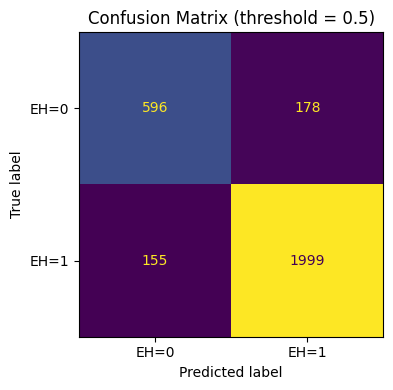

In [9]:
# Task 8: Classify all observations, construct confusion matrix, compute metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

task2_df['EH_pred'] = (task2_df['p_hat'] >= THRESHOLD_DEFAULT).astype(int)

y_true = task2_df['EH']
y_pred = task2_df['EH_pred']

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy    = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)   # True Positive Rate
specificity = tn / (tn + fp)   # True Negative Rate

print(f"Confusion Matrix (threshold = {THRESHOLD_DEFAULT}):")
print(f"  TN = {tn:4d}   FP = {fp:4d}")
print(f"  FN = {fn:4d}   TP = {tp:4d}")
print()
print(f"Accuracy    = {accuracy:.4f}  — fraction of all observations correctly classified")
print(f"Sensitivity = {sensitivity:.4f}  — fraction of true EH=1 correctly predicted (TPR / recall)")
print(f"Specificity = {specificity:.4f}  — fraction of true EH=0 correctly predicted (TNR)")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['EH=0', 'EH=1']).plot(ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix (threshold = {THRESHOLD_DEFAULT})')
plt.tight_layout()
plt.show()


## Task 9
Explain in your own words what ROC curve is. Why does ROC not depend on a specific threshold?

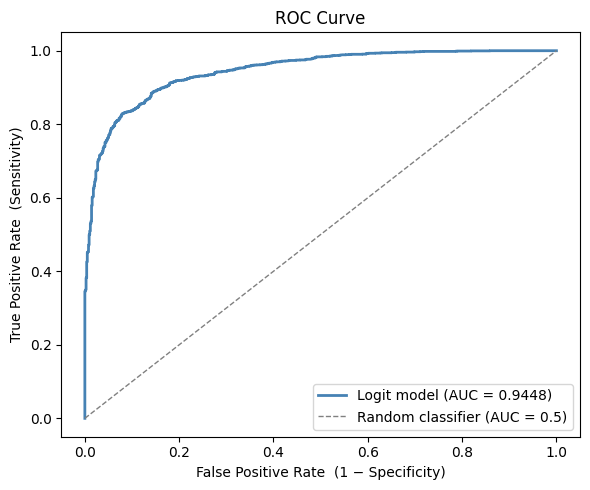

The ROC curve plots Sensitivity (TPR) vs. 1–Specificity (FPR) for every possible threshold.
It is threshold-independent because it evaluates the model across ALL thresholds at once,
capturing the overall trade-off between detecting true positives and generating false positives.


In [10]:
# Task 9: Plot ROC curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(task2_df['EH'], task2_df['p_hat'])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logit model (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate  (1 − Specificity)')
ax.set_ylabel('True Positive Rate  (Sensitivity)')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("The ROC curve plots Sensitivity (TPR) vs. 1–Specificity (FPR) for every possible threshold.")
print("It is threshold-independent because it evaluates the model across ALL thresholds at once,")
print("capturing the overall trade-off between detecting true positives and generating false positives.")


## Task 10
Using ROC curve, choose optimal threshold to classify observations. Consider at least three approaches to determine it and explain their ideas. For found thresholds, construct new confusion matrix and compute accuracy, sensitivity, specificity. Are new results better? Why?

Threshold comparison:
                  Threshold  Accuracy  Sensitivity  Specificity
Approach                                                       
Youden's J           0.7581    0.8531       0.8287       0.9212
Closest to (0,1)     0.6358    0.8777       0.8844       0.8592
Max F1               0.5370    0.8890       0.9188       0.8062
Default (0.5)        0.5000    0.8863       0.9280       0.7700


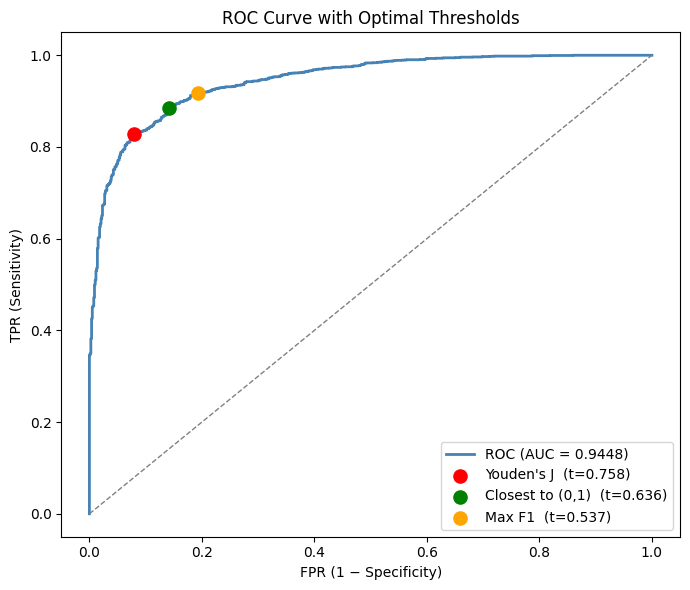

In [11]:
# Task 10: Optimal threshold — three approaches
from sklearn.metrics import f1_score

# --- Approach 1: Youden's J statistic — maximises (Sensitivity + Specificity − 1) ---
J = tpr - fpr
idx_youden = np.argmax(J)
threshold_youden = roc_thresholds[idx_youden]

# --- Approach 2: Closest point to (0, 1) — minimises Euclidean distance to perfect classifier ---
dist = np.sqrt(fpr**2 + (1 - tpr)**2)
idx_closest = np.argmin(dist)
threshold_closest = roc_thresholds[idx_closest]

# --- Approach 3: Maximise F1 score — balances precision and recall ---
f1_scores = [
    f1_score(task2_df['EH'], (task2_df['p_hat'] >= t).astype(int))
    for t in roc_thresholds
]
idx_f1 = np.argmax(f1_scores)
threshold_f1 = roc_thresholds[idx_f1]

# Helper: compute confusion-matrix-based metrics
def clf_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Threshold': None,
        'Accuracy':    round((tp + tn) / len(y_true), 4),
        'Sensitivity': round(tp / (tp + fn),           4),
        'Specificity': round(tn / (tn + fp),           4),
    }

rows = []
for approach, t in [("Youden's J",        threshold_youden),
                    ("Closest to (0,1)",   threshold_closest),
                    ("Max F1",             threshold_f1)]:
    preds = (task2_df['p_hat'] >= t).astype(int)
    m = clf_metrics(task2_df['EH'], preds)
    m['Threshold'] = round(t, 4)
    rows.append({'Approach': approach, **m})

# Add default 0.5 for comparison
preds_def = (task2_df['p_hat'] >= 0.5).astype(int)
m_def = clf_metrics(task2_df['EH'], preds_def)
m_def['Threshold'] = 0.5
rows.append({'Approach': 'Default (0.5)', **m_def})

results_df = pd.DataFrame(rows).set_index('Approach')
print("Threshold comparison:")
print(results_df.to_string())

# Plot ROC with optimal thresholds marked
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
colors = ['red', 'green', 'orange']
for (name, t), c in zip([("Youden's J", threshold_youden),
                          ("Closest to (0,1)", threshold_closest),
                          ("Max F1", threshold_f1)], colors):
    idx = np.argmin(np.abs(roc_thresholds - t))
    ax.scatter(fpr[idx], tpr[idx], color=c, s=90, zorder=5, label=f'{name}  (t={t:.3f})')
ax.set_xlabel('FPR (1 − Specificity)')
ax.set_ylabel('TPR (Sensitivity)')
ax.set_title('ROC Curve with Optimal Thresholds')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Task 11
Compute AUC. What does it show? Explain in your own words how to use it.

In [12]:
# Task 11: AUC — Area Under the ROC Curve
print(f"AUC = {roc_auc:.4f}")
print()
print("Interpretation:")
print("  AUC is the probability that the model assigns a higher predicted probability")
print("  to a randomly chosen positive case (EH=1) than to a randomly chosen negative case (EH=0).")
print()
print("  AUC = 1.00 → perfect separation (ideal classifier)")
print("  AUC = 0.50 → no discriminative power (same as random guessing)")
print(f"  AUC = {roc_auc:.4f} → strong discriminative ability")
print()
print("How to use it:")
print("  — Compare competing models: the model with a higher AUC generalises better.")
print("  — Threshold-free evaluation: useful when the optimal cut-off is not yet chosen.")
print("  — Robust to class imbalance: unlike accuracy, AUC is not biased by unequal class sizes.")


AUC = 0.9448

Interpretation:
  AUC is the probability that the model assigns a higher predicted probability
  to a randomly chosen positive case (EH=1) than to a randomly chosen negative case (EH=0).

  AUC = 1.00 → perfect separation (ideal classifier)
  AUC = 0.50 → no discriminative power (same as random guessing)
  AUC = 0.9448 → strong discriminative ability

How to use it:
  — Compare competing models: the model with a higher AUC generalises better.
  — Threshold-free evaluation: useful when the optimal cut-off is not yet chosen.
  — Robust to class imbalance: unlike accuracy, AUC is not biased by unequal class sizes.
